In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [11]:
df_country = pd.read_csv("co2_emissions_kt_by_country.csv")
df_country.head()

,country_code,country_name,year,value
0,ABW,Aruba,1960,11092.675
1,ABW,Aruba,1961,11576.719
2,ABW,Aruba,1962,12713.489
3,ABW,Aruba,1963,12178.107
4,ABW,Aruba,1964,11840.743


In [12]:
print(df_country.columns)
df_country.info()

Index(['country_code', 'country_name', 'year', 'value'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13953 entries, 0 to 13952
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  13953 non-null  object 
 1   country_name  13953 non-null  object 
 2   year          13953 non-null  int64  
 3   value         13953 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 436.2+ KB


In [13]:
df.isnull().sum()

country_code      0
country_name      0
year              0
value             0
lag_1             0
lag_2             0
lag_3             0
rolling_mean_3    0
dtype: int64

In [14]:
country_name = "Romania"   # change to any country you want
df = df[df["country_name"] == country_name].copy()

In [7]:
df["lag_1"] = df["value"].shift(1)
df["lag_2"] = df["value"].shift(2)
df["lag_3"] = df["value"].shift(3)
df["rolling_mean_3"] = df["value"].rolling(3).mean()

In [8]:
df = df.dropna().reset_index(drop=True)
df.head()

,country_code,country_name,year,value,lag_1,lag_2,lag_3,rolling_mean_3
0,ROU,Romania,1963,69529.987,63879.140,55775.070,53450.192,63061.399000
1,ROU,Romania,1964,72115.222,69529.987,63879.140,55775.070,68508.116333
2,ROU,Romania,1965,78723.156,72115.222,69529.987,63879.140,73456.121667
3,ROU,Romania,1966,84183.319,78723.156,72115.222,69529.987,78340.565667
4,ROU,Romania,1967,92129.708,84183.319,78723.156,72115.222,85012.061000


In [15]:
df.head()

,country_code,country_name,year,value,lag_1,lag_2,lag_3,rolling_mean_3
0,ROU,Romania,1963,69529.987,63879.140,55775.070,53450.192,63061.399000
1,ROU,Romania,1964,72115.222,69529.987,63879.140,55775.070,68508.116333
2,ROU,Romania,1965,78723.156,72115.222,69529.987,63879.140,73456.121667
3,ROU,Romania,1966,84183.319,78723.156,72115.222,69529.987,78340.565667
4,ROU,Romania,1967,92129.708,84183.319,78723.156,72115.222,85012.061000


In [16]:
df = df.sort_values("year")
df.reset_index(drop=True, inplace=True)

In [17]:
df[["country_name", "year", "value"]].head(10)

,country_name,year,value
0,Romania,1963,69529.987
1,Romania,1964,72115.222
2,Romania,1965,78723.156
3,Romania,1966,84183.319
4,Romania,1967,92129.708
5,Romania,1968,100189.774
6,Romania,1969,111649.149
7,Romania,1970,120112.585
8,Romania,1971,125829.438
9,Romania,1972,132422.704


In [18]:
df["lag_1"] = df["value"].shift(1)
df["lag_2"] = df["value"].shift(2)
df["lag_3"] = df["value"].shift(3)

In [19]:
df["rolling_mean_3"] = df["value"].rolling(3).mean()

In [20]:
df.head(10)

,country_code,country_name,year,value,lag_1,lag_2,lag_3,rolling_mean_3
0,ROU,Romania,1963,69529.987,NaN,NaN,NaN,NaN
1,ROU,Romania,1964,72115.222,69529.987,NaN,NaN,NaN
2,ROU,Romania,1965,78723.156,72115.222,69529.987,NaN,73456.121667
3,ROU,Romania,1966,84183.319,78723.156,72115.222,69529.987,78340.565667
4,ROU,Romania,1967,92129.708,84183.319,78723.156,72115.222,85012.061000
5,ROU,Romania,1968,100189.774,92129.708,84183.319,78723.156,92167.600333
6,ROU,Romania,1969,111649.149,100189.774,92129.708,84183.319,101322.877000
7,ROU,Romania,1970,120112.585,111649.149,100189.774,92129.708,110650.502667
8,ROU,Romania,1971,125829.438,120112.585,111649.149,100189.774,119197.057333
9,ROU,Romania,1972,132422.704,125829.438,120112.585,111649.149,126121.575667


In [21]:
target = "value"
X = df[["year", "lag_1", "lag_2", "lag_3", "rolling_mean_3"]]
y = df[target]

In [22]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (57, 5)
Target shape: (57,)


In [23]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [24]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (45, 5)
X_test: (12, 5)
y_train: (45,)
y_test: (12,)


In [25]:
model = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

In [26]:
model.fit(X_train, y_train)

,n_estimators,150
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = model.predict(X_test)

In [28]:
print(y_pred[:10])

[95986.55015456 95890.93216033 93487.05137037 92255.22519437
 93322.36569217 93258.70334619 91591.43119161 90508.62116256
 90245.85872641 90245.85872641]


In [29]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 14723.528514444219
RMSE: 15691.437750911555
R2 Score: -4.480171592471972


In [30]:
results = pd.DataFrame({
    "Year": X_test["year"].values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Year,Actual,Predicted
0,2008,95419.998169,95986.550155
1,2009,80709.999084,95890.932160
2,2010,77620.002747,93487.051370
3,2011,84059.997559,92255.225194
4,2012,81849.998474,93322.365692
5,2013,72089.996338,93258.703346
6,2014,71540.000916,91591.431192
7,2015,73319.999695,90508.621163
8,2016,71589.996338,90245.858726
9,2017,74209.999084,90245.858726


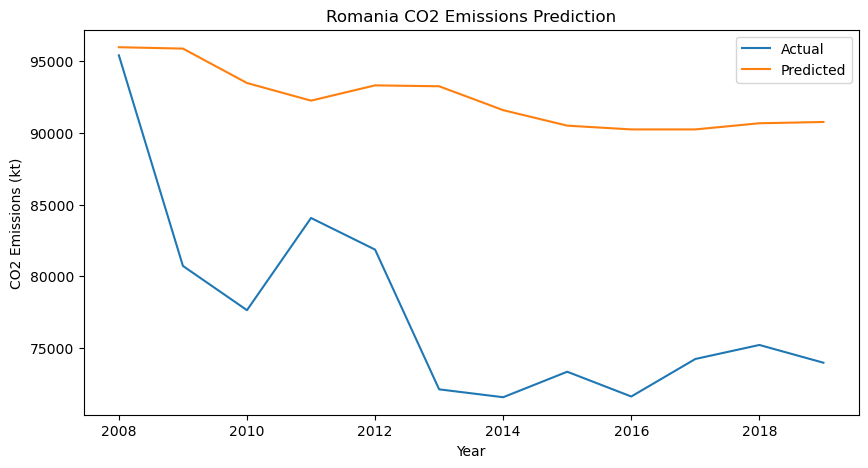

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(results["Year"], results["Actual"], label="Actual")
plt.plot(results["Year"], results["Predicted"], label="Predicted")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions (kt)")
plt.title(f"{country_name} CO2 Emissions Prediction")
plt.legend()
plt.show()

In [32]:
joblib.dump(model, "country_co2_model.joblib")
print("Model saved successfully!")

Model saved successfully!


In [33]:
loaded_model = joblib.load("country_co2_model.joblib")
print("Model loaded successfully!")

Model loaded successfully!
